# Métodos Numéricos para Encontrar Raízes
Esta aula aborda os métodos de bissecção, Newton-Raphson e secante, com critérios de parada flexíveis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Função de exemplo
Vamos usar f(x) = 5x³ - 8x - 0.5 como exemplo.

In [2]:
def f(x):
    return 5*x**3 - 8*x - 0.5

## Gráfico da função

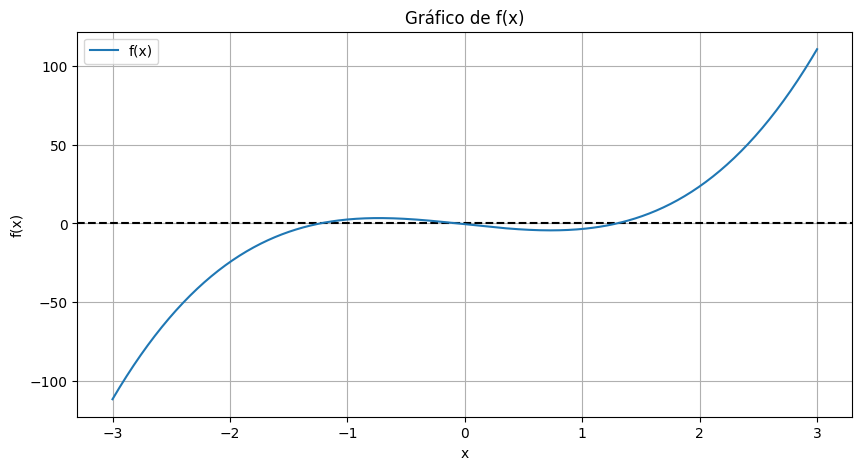

In [3]:
x_vals = np.linspace(-3, 3, 400)
y_vals = np.array([f(x) for x in x_vals])
plt.figure(figsize=(10,5))
plt.axhline(0, color='black', linestyle='--')
plt.plot(x_vals, y_vals, label='f(x)')
plt.title('Gráfico de f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

## Método da Bissecção com critérios flexíveis

In [4]:
def bissecao_flex(f, a, b, tol=1e-6, max_iter=100, mode='func'):
    if a > b:
        a, b = b, a
    fa, fb = f(a), f(b)
    if fa == 0:
        return a, [a]
    if fb == 0:
        return b, [b]
    if fa * fb > 0:
        raise ValueError('Intervalo não possui mudança de sinal.')
    historico = []
    p = None
    for _ in range(max_iter):
        p = 0.5 * (a + b)
        fp = f(p)
        historico.append(p)
        stop_func = abs(fp) < tol
        stop_intervalo = 0.5 * (b - a) < tol
        if mode == 'func' and stop_func:
            return p, historico
        if mode == 'intervalo' and stop_intervalo:
            return p, historico
        if mode == 'ambos' and (stop_func or stop_intervalo):
            return p, historico
        if fa * fp < 0:
            b, fb = p, fp
        else:
            a, fa = p, fp
    return p, historico

## Método de Newton-Raphson com dois critérios de parada

In [5]:
def newton_raphson_duplo_criterio(f, df, x0, eps1=1e-6, eps2=1e-6, max_iter=50):
    x = x0
    historico = [x0]
    for k in range(max_iter):
        fx = f(x)
        dfx = df(x)
        if dfx == 0:
            raise ZeroDivisionError('Derivada zero. Método falhou.')
        x_new = x - fx/dfx
        historico.append(x_new)
        crit1 = abs(f(x_new)) < eps1
        crit2 = abs(x_new - x) < eps2
        if crit1:
            return x_new, historico, k+1, 'funcional (|f(x)| < eps1)'
        if crit2:
            return x_new, historico, k+1, 'intervalar (|x_{k+1} - x_k| < eps2)'
        x = x_new
    return x, historico, max_iter, 'máximo de iterações'

## Método da Secante com dois critérios de parada

In [6]:
def secante_duplo_criterio(f, x0, x1, eps1=1e-6, eps2=1e-6, max_iter=50):
    historico = [x0, x1]
    for k in range(max_iter):
        fx0, fx1 = f(x0), f(x1)
        denom = fx1 - fx0
        if denom == 0:
            raise ZeroDivisionError('Secante falhou: f(x1) - f(x0) = 0.')
        x2 = x1 - fx1 * (x1 - x0) / denom
        historico.append(x2)
        crit1 = abs(f(x2)) < eps1
        crit2 = abs(x2 - x1) < eps2
        if crit1:
            return x2, historico, k+1, 'funcional (|f(x)| < eps1)'
        if crit2:
            return x2, historico, k+1, 'intervalar (|x_{k+1} - x_k| < eps2)'
        x0, x1 = x1, x2
    return x2, historico, max_iter, 'máximo de iterações'

## Exemplos de uso

In [7]:
# Bissecção
p, hist = bissecao_flex(f, -2, 2, tol=1e-6, mode='func')
print(f'Bissecção: raiz ≈ {p:.8f}, histórico: {hist}')

Bissecção: raiz ≈ 1.29507363, histórico: [0.0, 1.0, 1.5, 1.25, 1.375, 1.3125, 1.28125, 1.296875, 1.2890625, 1.29296875, 1.294921875, 1.2958984375, 1.29541015625, 1.295166015625, 1.2950439453125, 1.29510498046875, 1.295074462890625, 1.2950592041015625, 1.2950668334960938, 1.2950706481933594, 1.2950725555419922, 1.2950735092163086, 1.2950739860534668, 1.2950737476348877, 1.2950736284255981]


In [8]:
# Newton-Raphson
df = lambda x: 15*x**2 - 8
raiz, hist, iter_stop, crit_stop = newton_raphson_duplo_criterio(f, df, x0=2.0)
print(f'Newton-Raphson: raiz ≈ {raiz}, histórico: {hist}')
print(f'Parou na iteração: {iter_stop} pelo critério: {crit_stop}')

Newton-Raphson: raiz ≈ 1.2950736224590094, histórico: [2.0, 1.5480769230769231, 1.3453605984735342, 1.297705276815199, 1.2950814274433025, 1.2950736224590094]
Parou na iteração: 5 pelo critério: funcional (|f(x)| < eps1)


In [ ]:
# Secante
raiz, hist, iter_stop, crit_stop = secante_duplo_criterio(f, 1.0, 2.0)
print(f'Secante: raiz ≈ {raiz}, histórico: {hist}')
print(f'Parou na iteração: {iter_stop} pelo critério: {crit_stop}')

Secante: raiz ≈ 1.2950736223828148, histórico: [1.0, 2.0, 1.1296296296296298, 1.2081306262061315, 1.3159725802663729, 1.2928922294629739, 1.2950228412316098, 1.295073748050411, 1.2950736223828148]
Parou na iteração: 7 pelo critério: funcional (|f(x)| < eps1)


: 